<a href="https://colab.research.google.com/github/cristianzucconi2-web/iatoarts/blob/main/IATORATS_FINALE_11GIUGNO_(2parte).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

# ==============================================================================
# 1. CARICAMENTO E ESTRAZIONE DELLO ZIP (DATASET DI ADDESTRAMENTO)
# ==============================================================================
print("1️⃣ Carica il file dataset.zip contenente le cartelle degli stili:")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('data_stili')

base_extracted = 'data_stili'
contenuto = os.listdir(base_extracted)
if len(contenuto) == 1 or (len(contenuto) == 2 and '__MACOSX' in contenuto):
    nome_cartella_reale = [f for f in contenuto if f != '__MACOSX'][0]
    DATA_DIR_TEMP = os.path.join(base_extracted, nome_cartella_reale)
else:
    DATA_DIR_TEMP = base_extracted

# ==============================================================================
# 2. CREAZIONE CARTELLA PULITA E FILTRAGGIO IMMAGINI
# ==============================================================================
print("\n2️⃣ Pulizia e ottimizzazione delle immagini del dataset...")
DATA_DIR = 'dataset_perfetto'
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

formati_validi = ('jpeg', 'png', 'gif', 'bmp', 'webp')

for stile in os.listdir(DATA_DIR_TEMP):
    percorso_stile_orig = os.path.join(DATA_DIR_TEMP, stile)
    if not os.path.isdir(percorso_stile_orig) or stile.startswith('.'):
        continue

    percorso_stile_nuovo = os.path.join(DATA_DIR, stile)
    os.makedirs(percorso_stile_nuovo, exist_ok=True)

    for immagine in os.listdir(percorso_stile_orig):
        file_orig = os.path.join(percorso_stile_orig, immagine)
        file_nuovo = os.path.join(percorso_stile_nuovo, immagine)
        if os.path.isfile(file_orig) and not immagine.startswith('.'):
            try:
                with Image.open(file_orig) as img:
                    if img.format.lower() in formati_validi:
                        shutil.copy(file_orig, file_nuovo)
            except:
                pass

print(f"✨ Cartella ottimizzata creata: '{DATA_DIR}'")

# ==============================================================================
# 3. PREPARAZIONE DEI DATASET (OTTIMIZZATO PER DATASET PICCOLI - 20 IMG)
# ==============================================================================
# Usiamo un batch piccolo (4) perché il dataset ha pochissimi elementi
BATCH_SIZE = 4
IMG_SIZE = (224, 224)

# Teniamo il 10% per la validazione (~2 immagini per classe) e il 90% per il training
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.1, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.1, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

class_names = train_ds.class_names
print("\n✅ Classi pronte dal dataset:", class_names)

# Data Augmentation aggressiva: fondamentale con sole 20 immagini per classe
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.15)
])

# ==============================================================================
# 4. CREAZIONE MODELLO (TRANSFER LEARNING CON MOBILENETV2)
# ==============================================================================
# Carichiamo i pesi di ImageNet. Il modello rimane COMPLETAMENTE CONGELATO.
# Con 20 immagini, fare fine-tuning profondo distruggerebbe l'accuratezza.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,  # Genera nuove variazioni a ogni epoca
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),  # Aumentato a 0.5 per contrastare il forte rischio di overfit
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================================================================
# 5. ADDESTRAMENTO DELLA TESTA DEL MODELLO
# ==============================================================================
print("\n3️⃣ Inizio addestramento (il modello estrarrà le caratteristiche apprese da ImageNet)...")
# Essendo i batch molto piccoli, aumentiamo leggermente le epoche per stabilizzare l'apprendimento
epochs = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

print("\n🎉 Modello addestrato con successo ed ottimizzato per contesti Few-Shot!")
print("-" * 80)



1️⃣ Carica il file dataset.zip contenente le cartelle degli stili:


Saving dataset_training (2).zip to dataset_training (2) (3).zip

2️⃣ Pulizia e ottimizzazione delle immagini del dataset...
✨ Cartella ottimizzata creata: 'dataset_perfetto'
Found 75 files belonging to 4 classes.
Using 68 files for training.
Found 75 files belonging to 4 classes.
Using 7 files for validation.

✅ Classi pronte dal dataset: ['Astrattismo', 'Impressionismo', 'Pop_Art', 'Rinascimento']

3️⃣ Inizio addestramento (il modello estrarrà le caratteristiche apprese da ImageNet)...
Epoch 1/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.3088 - loss: 1.9019 - val_accuracy: 0.5714 - val_loss: 0.7155
Epoch 2/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5882 - loss: 0.9997 - val_accuracy: 1.0000 - val_loss: 0.2793
Epoch 3/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8529 - loss: 0.3312 - val_accuracy: 0.8571 - val_loss: 0.4494
Epoch 4/15
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8088 - loss: 0.5790 - val_accuracy: 0.8571 - val_loss: 0.2902

Seed impostato correttamente. Risultati riproducibili al 100%!

--- FASE 1: Caricamento del dataset ---


Saving dataset_training (2).zip to dataset_training (2) (4).zip
Estrazione completata!
Pulizia file nascosti completata.

--- FASE 2: Configurazione dei Dati e dei Dataset ---
Dispositivo in uso: cuda
Classi rilevate: ['Astrattismo', 'Impressionismo', 'Pop_Art', 'Rinascimento']
Modello ResNet50 ottimizzato per contesti Few-Shot configurato.

--- FASE 3: Inizio Addestramento (Monitoraggio Real-Time) ---
Epoca 01/20 -> Loss Tr: 1.371 | Acc Tr: 0.281 || Loss Val: 1.344 | Acc Val: 0.438
Epoca 02/20 -> Loss Tr: 1.308 | Acc Tr: 0.484 || Loss Val: 1.303 | Acc Val: 0.312
Epoca 03/20 -> Loss Tr: 1.210 | Acc Tr: 0.609 || Loss Val: 1.240 | Acc Val: 0.438
Epoca 04/20 -> Loss Tr: 1.155 | Acc Tr: 0.609 || Loss Val: 1.192 | Acc Val: 0.500
Epoca 05/20 -> Loss Tr: 1.066 | Acc Tr: 0.672 || Loss Val: 1.123 | Acc Val: 0.625
Epoca 06/20 -> Loss Tr: 1.008 | Acc Tr: 0.703 || Loss Val: 1.034 | Acc Val: 0.625
Epoca 07/20 -> Loss Tr: 0.885 | Acc Tr: 0.766 || Loss Val: 0.939 | Acc Val: 0.625
Epoca 08/20 -> Loss 

Saving WhatsApp Image 2026-06-11 at 12.07.10.jpeg to WhatsApp Image 2026-06-11 at 12.07.10.jpeg
Saving WhatsApp Image 2026-06-11 at 12.07.09 (4).jpeg to WhatsApp Image 2026-06-11 at 12.07.09 (4).jpeg
Saving WhatsApp Image 2026-06-11 at 12.07.09 (3).jpeg to WhatsApp Image 2026-06-11 at 12.07.09 (3).jpeg
Saving WhatsApp Image 2026-06-11 at 12.07.09 (2).jpeg to WhatsApp Image 2026-06-11 at 12.07.09 (2).jpeg
Saving WhatsApp Image 2026-06-11 at 12.07.09 (1).jpeg to WhatsApp Image 2026-06-11 at 12.07.09 (1).jpeg
Saving WhatsApp Image 2026-06-11 at 12.07.09.jpeg to WhatsApp Image 2026-06-11 at 12.07.09.jpeg

FILE ANALIZZATO: WhatsApp Image 2026-06-11 at 12.07.10.jpeg
VERDETTO: IMPRESSIONISMO (81.52%)


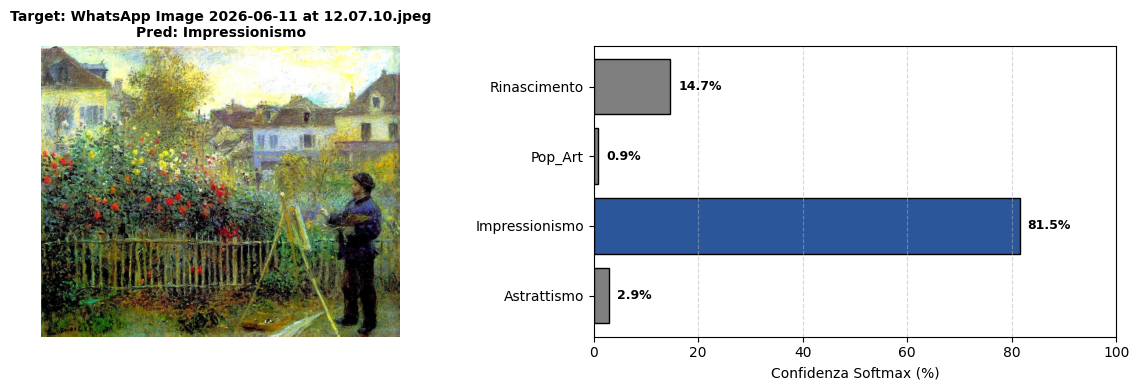


------------------------------------------------------------


FILE ANALIZZATO: WhatsApp Image 2026-06-11 at 12.07.09 (4).jpeg
VERDETTO: RINASCIMENTO (87.67%)


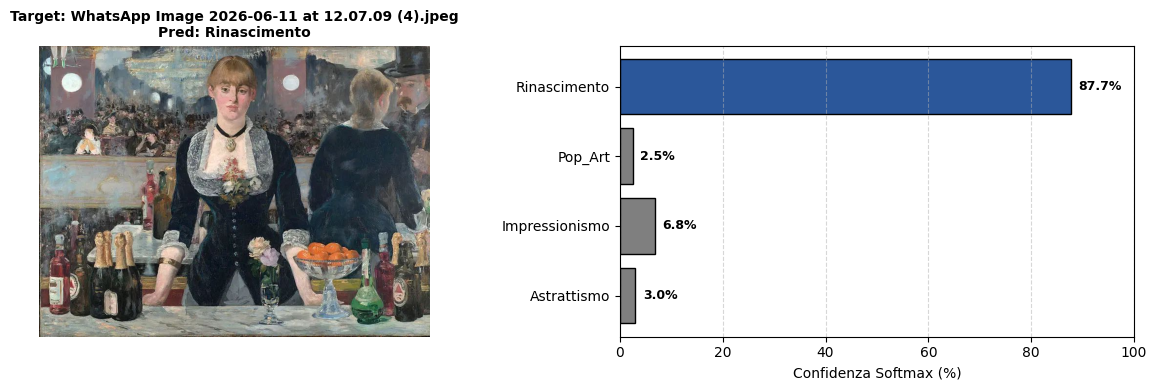


------------------------------------------------------------


FILE ANALIZZATO: WhatsApp Image 2026-06-11 at 12.07.09 (3).jpeg
VERDETTO: IMPRESSIONISMO (76.04%)


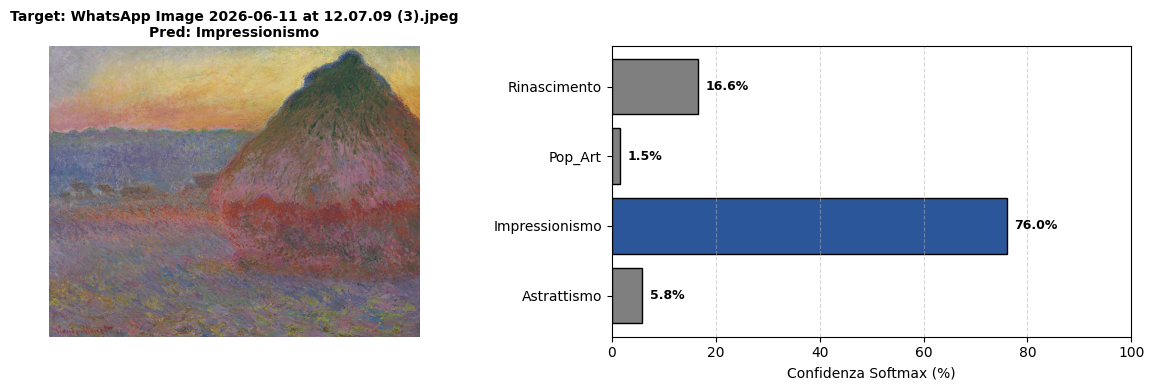


------------------------------------------------------------


FILE ANALIZZATO: WhatsApp Image 2026-06-11 at 12.07.09 (2).jpeg
VERDETTO: IMPRESSIONISMO (64.46%)


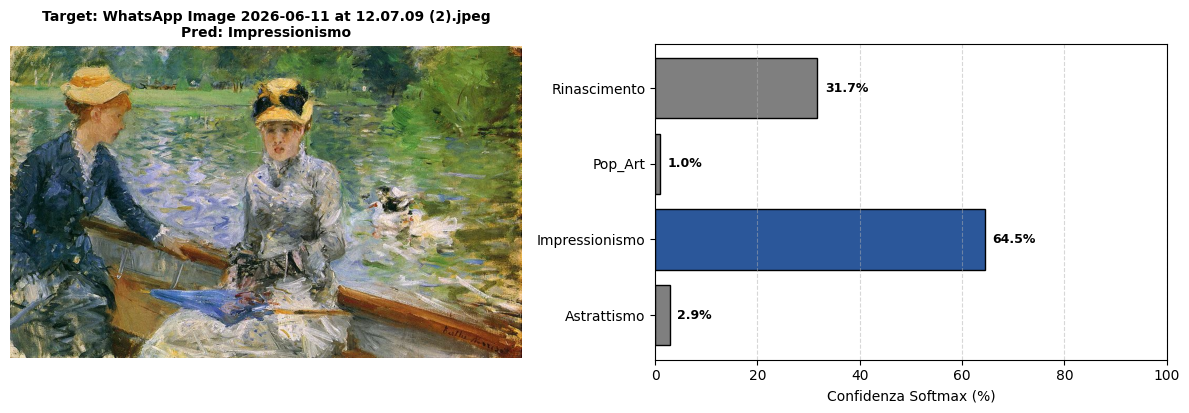


------------------------------------------------------------


FILE ANALIZZATO: WhatsApp Image 2026-06-11 at 12.07.09 (1).jpeg
VERDETTO: IMPRESSIONISMO (71.00%)


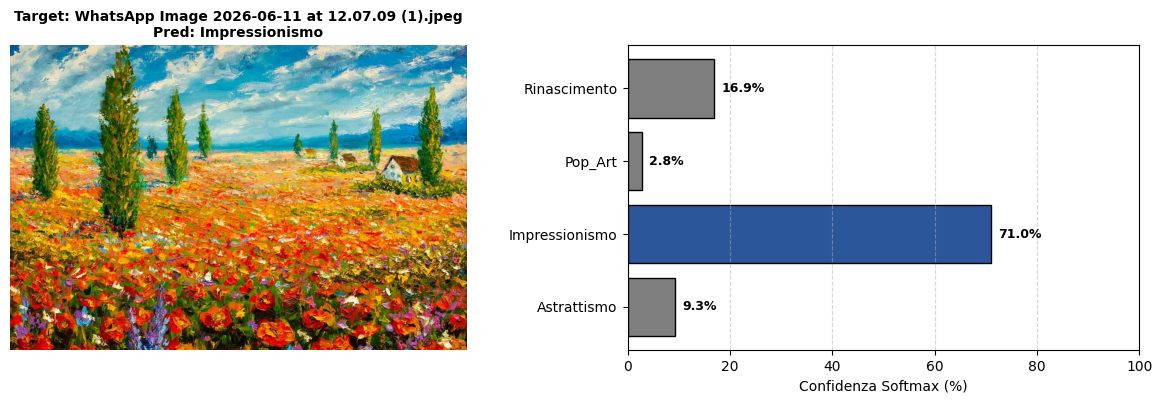


------------------------------------------------------------


FILE ANALIZZATO: WhatsApp Image 2026-06-11 at 12.07.09.jpeg
VERDETTO: IMPRESSIONISMO (65.65%)


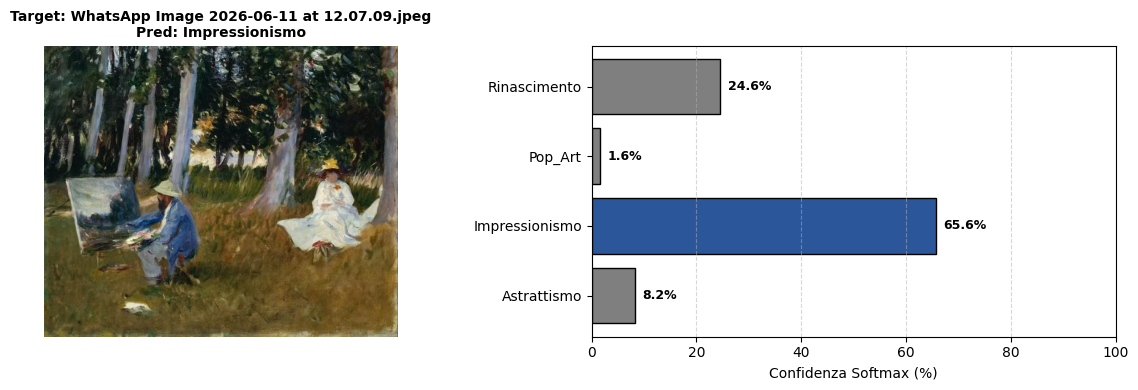


------------------------------------------------------------


[INFO] Test completato.


In [ ]:
import os
import zipfile
import shutil
import random
import io
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 0. FISSARE IL SEED PER IL DETERMINISMO
# =====================================================================
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed impostato correttamente. Risultati riproducibili al 100%!")

# =====================================================================
# 1. CARICAMENTO E PULIZIA DELLO ZIP
# =====================================================================
print("\n--- FASE 1: Caricamento del dataset ---")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('dataset_arte')
print("Estrazione completata!")

macosx_path = 'dataset_arte/__MACOSX'
if os.path.exists(macosx_path):
    shutil.rmtree(macosx_path)

for root, dirs, files_list in os.walk('dataset_arte'):
    for file in files_list:
        if file.startswith('._'):
            os.remove(os.path.join(root, file))
print("Pulizia file nascosti completata.\n")

# =====================================================================
# 2. DATA AUGMENTATION E SPLIT TRAIN/VAL (FONDAMENTALE)
# =====================================================================
print("--- FASE 2: Configurazione dei Dati e dei Dataset ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

# Augmentation avanzata per il Training (texture e variazioni di luce)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15)
    ], p=0.6),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5))
    ], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validazione pulita: solo resize e normalizzazione
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

base_path = 'dataset_arte'
if len(os.listdir(base_path)) == 1 and os.path.isdir(os.path.join(base_path, os.listdir(base_path)[0])):
    base_path = os.path.join(base_path, os.listdir(base_path)[0])

# Creiamo due istanze dello stesso dataset per applicare trasformazioni separate
full_dataset_train = datasets.ImageFolder(root=base_path, transform=train_transforms)
full_dataset_val = datasets.ImageFolder(root=base_path, transform=val_transforms)
class_names = full_dataset_train.classes
print(f"Classi rilevate: {class_names}")

# Generazione split bilanciato (80% Train, 20% Validazione -> ~6 immagini di controllo per classe)
num_samples = len(full_dataset_train)
indices = list(range(num_samples))
np.random.shuffle(indices)
split = int(np.floor(0.2 * num_samples))
train_idx, val_idx = indices[split:], indices[:split]

train_dataset = Subset(full_dataset_train, train_idx)
val_dataset = Subset(full_dataset_val, val_idx)

# Batch size a 8 per gestire l'aggiornamento dei pesi su pochissimi dati senza saltare i minimi locali
BATCH_SIZE = 8
g = torch.Generator().manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =====================================================================
# 3. STRATEGIA RESNET50 CON TESTA LEGGERA E REGOLARIZZATA
# =====================================================================
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Congeliamo la spina dorsale iniziale
for param in model.parameters():
    param.requires_grad = False

# Sblocchiamo i blocchi alti per sintonizzarli sulle pennellate e lo stile macro
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features

# Testa snella (64 neuroni) + Dropout alto per impedire l'overfitting su 30 immagini
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, len(class_names))
)
model = model.to(device)

# Aggiunto weight_decay (L2) per stabilizzare i layer convoluzionali aperti
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-6, 'weight_decay': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.fc.parameters(), 'lr': 3e-4}
])

criterion = nn.CrossEntropyLoss()
print("Modello ResNet50 ottimizzato per contesti Few-Shot configurato.\n")

# =====================================================================
# 4. ADDESTRAMENTO CON MONITORAGGIO DELLA VALIDAZIONE
# =====================================================================
print("--- FASE 3: Inizio Addestramento (Monitoraggio Real-Time) ---")
epochs = 20

for epoch in range(epochs):
    # FASE DI TRAINING
    model.train()
    train_loss, train_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_train_acc = train_corrects.double() / len(train_dataset)

    # FASE DI VALIDAZIONE (La bussola del modello)
    model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_corrects.double() / len(val_dataset)

    print(f"Epoca {epoch+1:02d}/{epochs} -> "
          f"Loss Tr: {epoch_train_loss:.3f} | Acc Tr: {epoch_train_acc:.3f} || "
          f"Loss Val: {epoch_val_loss:.3f} | Acc Val: {epoch_val_acc:.3f}")

print("\nAddestramento completato con successo!\n")

# =====================================================================
# 5. INFERENZA GRAFICA DI PRECISIONE
# =====================================================================
print("\n" + "="*60)
print(" [AI INFERENZA] SELEZIONE IMMAGINI DI TEST")
print("="*60)

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

uploaded_images = files.upload()

if not uploaded_images:
    print("[INFO] Nessuna immagine selezionata per il test.")
else:
    model.eval()

    for img_name, img_data in uploaded_images.items():
        try:
            img_pil = Image.open(io.BytesIO(img_data)).convert('RGB')
        except Exception as e:
            print(f"\n[SALTATO] File non valido: {img_name}")
            continue

        input_tensor = test_transforms(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)
            predizioni = torch.nn.functional.softmax(outputs, dim=1)[0].cpu().numpy()

        corrente_scelta_idx = np.argmax(predizioni)
        confidenza = predizioni[corrente_scelta_idx] * 100

        print("\n" + "="*50)
        print(f"FILE ANALIZZATO: {img_name}")
        print(f"VERDETTO: {class_names[corrente_scelta_idx].upper()} ({confidenza:.2f}%)")
        print("="*50)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.imshow(np.array(img_pil))
        ax1.set_title(f"Target: {img_name}\nPred: {class_names[corrente_scelta_idx]}", fontsize=10, fontweight='bold')
        ax1.axis('off')

        colors = ['#7f7f7f'] * len(class_names)
        colors[corrente_scelta_idx] = '#2B579A'

        barre = ax2.barh(class_names, predizioni * 100, color=colors, edgecolor='black')
        ax2.set_xlabel('Confidenza Softmax (%)')
        ax2.set_xlim(0, 100)
        ax2.grid(axis='x', linestyle='--', alpha=0.5)

        for barra in barre:
            width = barra.get_width()
            ax2.text(width + 1.5, barra.get_y() + barra.get_height()/2, f'{width:.1f}%',
                     va='center', ha='left', fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.show()
        print("\n" + "-"*60 + "\n")

print("\n[INFO] Test completato.")